In [1]:
from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [2]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Dataset information

print("Shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

Shape: (7043, 21)

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate rows:
0

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessB

In [4]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Remove rows with missing values
df.dropna(inplace=True)

# Check final shape
print("Final dataset shape:", df.shape)

Final dataset shape: (7032, 21)


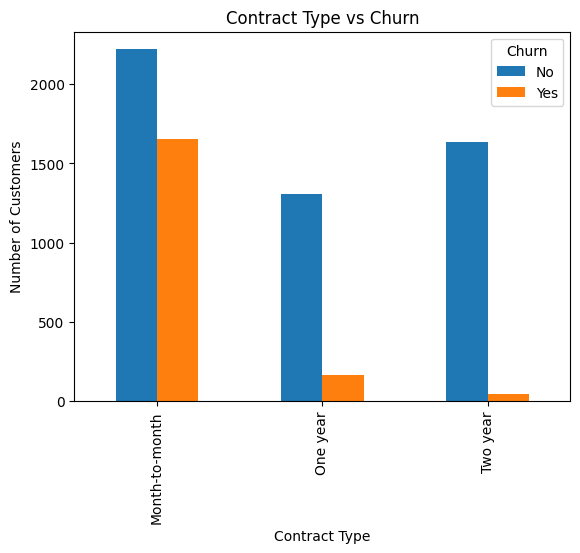

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Create comparison table
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"]
)

# Plot graph
contract_churn.plot(kind="bar")

# Add labels
plt.title("Contract Type vs Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

# Show graph
plt.show()

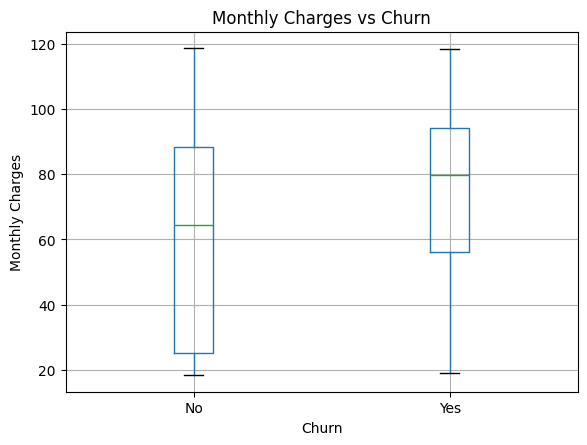

In [6]:
import matplotlib.pyplot as plt

# Create boxplot
df.boxplot(
    column="MonthlyCharges",
    by="Churn"
)

plt.title("Monthly Charges vs Churn")
plt.suptitle("")   # removes extra automatic title

plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [7]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

# Convert all text columns into numbers
for column in df.columns:

    if df[column].dtype == "object":

        df[column] = encoder.fit_transform(
            df[column]
        )

print(df.head())

   customerID  gender  SeniorCitizen  Partner  Dependents  tenure  \
0        5365       0              0        1           0       1   
1        3953       1              0        0           0      34   
2        2558       1              0        0           0       2   
3        5524       1              0        0           0      45   
4        6500       0              0        0           0       2   

   PhoneService  MultipleLines  InternetService  OnlineSecurity  ...  \
0             0              1                0               0  ...   
1             1              0                0               2  ...   
2             1              0                0               2  ...   
3             0              1                0               2  ...   
4             1              0                1               0  ...   

   DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract  \
0                 0            0            0                0         0   


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Features
X = df.drop("Churn", axis=1)

# Target
y = df["Churn"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Scale data
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# Train model
model = LogisticRegression(max_iter=2000)

model.fit(X_train, y_train)

print("Professional model training completed")

Professional model training completed


In [9]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Predictions
predictions = model.predict(X_test)

# Classification report
print("Classification Report:\n")
print(classification_report(y_test, predictions))

# Confusion matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, predictions))

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407


Confusion Matrix:

[[922 111]
 [190 184]]


In [10]:
# Churn percentage
churn_rate = (df["Churn"].mean()) * 100

print("Churn Rate:", round(churn_rate,2), "%")


# Average monthly charges by churn status
monthly_charge_analysis = df.groupby(
    "Churn"
)["MonthlyCharges"].mean()

print("\nAverage Monthly Charges:\n")
print(monthly_charge_analysis)


# Average tenure by churn status
tenure_analysis = df.groupby(
    "Churn"
)["tenure"].mean()

print("\nAverage Tenure:\n")
print(tenure_analysis)

Churn Rate: 26.58 %

Average Monthly Charges:

Churn
0    61.307408
1    74.441332
Name: MonthlyCharges, dtype: float64

Average Tenure:

Churn
0    37.650010
1    17.979133
Name: tenure, dtype: float64


In [11]:
import pandas as pd

# Convert scaled test data back to DataFrame
results = pd.DataFrame(
    X_test,
    columns=X.columns
)

# Add actual and predicted values
results["Actual_Churn"] = y_test.values
results["Predicted_Churn"] = predictions

# Save file
results.to_csv(
    "prediction_results.csv",
    index=False
)

print("Prediction results exported successfully")

Prediction results exported successfully


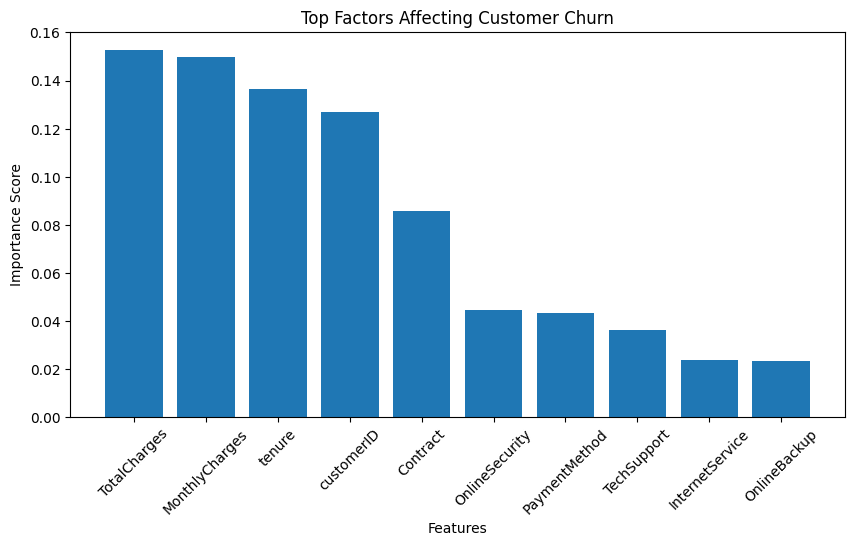

In [12]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt

# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

# Get importance scores
importance = rf.feature_importances_

# Create DataFrame
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

# Sort values
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Show top 10 features
top10 = feature_importance.head(10)

# Plot
plt.figure(figsize=(10,5))

plt.bar(
    top10["Feature"],
    top10["Importance"]
)

plt.xticks(rotation=45)

plt.title("Top Factors Affecting Customer Churn")

plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.show()

In [13]:
# Generate business summary

print("========== EXECUTIVE BUSINESS SUMMARY ==========\n")

print("1. Customer churn rate:",
      round((df["Churn"].mean())*100,2), "%")

print("\n2. Key churn drivers identified:")

for feature in top10["Feature"].head(5):
    print("-", feature)

print("\n3. Business recommendations:")

print("- Offer discounts for high-risk customers")
print("- Encourage customers to move from monthly to yearly contracts")
print("- Create retention plans for customers with short tenure")
print("- Monitor customers with high monthly charges")

print("\n================================================")


========== EXECUTIVE BUSINESS SUMMARY ==========

1. Customer churn rate: 26.58 %

2. Key churn drivers identified:
- TotalCharges
- MonthlyCharges
- tenure
- customerID
- Contract

3. Business recommendations:
- Offer discounts for high-risk customers
- Encourage customers to move from monthly to yearly contracts
- Create retention plans for customers with short tenure
- Monitor customers with high monthly charges



In [14]:
# Create dashboard dataset

dashboard_data = df.copy()

# Add churn label back as readable text
dashboard_data["Churn_Label"] = dashboard_data["Churn"].replace(
    {
        0:"No",
        1:"Yes"
    }
)

# Save dashboard dataset
dashboard_data.to_csv(
    "powerbi_dashboard_data.csv",
    index=False
)

print("Dashboard dataset exported successfully")

Dashboard dataset exported successfully


In [15]:
import sqlite3

# Create database
connection = sqlite3.connect(
    "customer_churn.db"
)

# Save data into table
df.to_sql(
    "customers",
    connection,
    if_exists="replace",
    index=False
)

print("Database created successfully")

Database created successfully


In [16]:
from google.colab import files

files.download("powerbi_dashboard_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
df.to_csv(
    "cleaned_customer_churn.csv",
    index=False
)

print("cleaned_customer_churn.csv created")

cleaned_customer_churn.csv created


In [23]:
from google.colab import files

files.download("powerbi_dashboard_data.csv")
files.download("prediction_results.csv")
files.download("customer_churn.db")
files.download("cleaned_customer_churn.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>